In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.patches as mpatches

In [3]:
# 1) LOAD
control_df = pd.read_csv("../data/Salmonella Enteretidis_Control.csv")
lmf_df = pd.read_csv("../data/Salmonella Enteretidis_LMF.csv")
control_df["phenotype"] = "Control"
lmf_df["phenotype"] = "LMF"
df = pd.concat([control_df, lmf_df], ignore_index=True)

In [31]:
# ---------------------------------------------------------
# 2. FILTER (Relaxed to prevent data loss)
# ---------------------------------------------------------
# Check for both spellings of Enteritidis/Enteretidis just in case
df = df[(df["#Organism group"] == "Salmonella enterica") & 
        (df["Serovar"].astype(str).str.contains("Enteritidis|Enteretidis", case=False, na=False))]

df = df[~df["Isolation type"].astype(str).str.lower().str.contains("clinical", na=False)]

# Relax the computed types string to just check for the serovar name
valid_computed = df["Computed types"].astype(str).str.contains("Enteritidis|Enteretidis", case=False, na=False)
df_final = df[valid_computed].copy()

# Drop rows without a SNP cluster
df_final = df_final[df_final["SNP cluster"].notna()].copy()

# Optional: Print out how many rows survived to verify!
print(f"Total rows after filtering: {len(df_final)}")

Total rows after filtering: 2903


In [33]:
# ---------------------------------------------------------
# 3. PREPARE PLOTTING DATA
# ---------------------------------------------------------
# A. Temporal
# coerce errors so bad date formats don't break the code, though normally they are fine
df_final['Year'] = pd.to_datetime(df_final['Create date'], errors='coerce').dt.year

# B. Source Categories
def get_source_category(row):
    s = str(row['Isolation source']).lower()
    if row['phenotype'] == 'Control':
        return 'Poultry (Control)'
    if any(x in s for x in ['almond', 'pistachio', 'nut', 'pecan', 'walnut']): return 'Nuts'
    if any(x in s for x in ['spice', 'pepper', 'cumin', 'powder', 'chili', 'seasoning']): return 'Spices'
    if any(x in s for x in ['flour', 'cake', 'cookie', 'bakery', 'wheat']): return 'Bakery/Flour'
    return 'Other LMF'

df_final['Source_Category'] = df_final.apply(get_source_category, axis=1)

# C. Cluster Data
cluster_counts = df_final.groupby(["SNP cluster", "phenotype"]).size().unstack(fill_value=0)
for col in ["LMF", "Control"]:
    if col not in cluster_counts.columns: cluster_counts[col] = 0

conditions = [
    (cluster_counts['LMF'] > 0) & (cluster_counts['Control'] > 0),
    (cluster_counts['LMF'] > 0) & (cluster_counts['Control'] == 0),
    (cluster_counts['LMF'] == 0) & (cluster_counts['Control'] > 0)
]
choices = ['Mixed Lineage', 'LMF Exclusive', 'Non-LMF Exclusive']
cluster_counts['Lineage_Type'] = np.select(conditions, choices, default='Unknown')

cluster_counts['LMF_plot'] = cluster_counts['LMF'] + 0.5
cluster_counts['Control_plot'] = cluster_counts['Control'] + 0.5

Figure 3 (Landscape) generated.


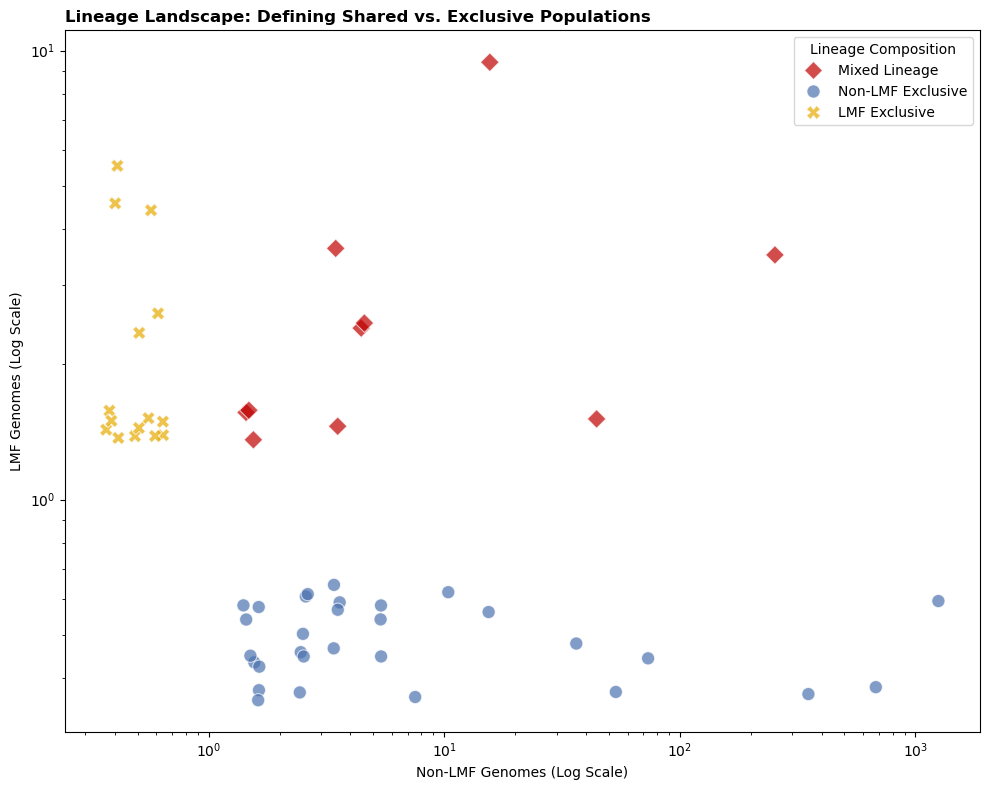

In [43]:
# ---------------------------------------------------------
# 4. PLOT FIGURE 3 (With Jitter to prevent overplotting)
# ---------------------------------------------------------
fig3, ax3 = plt.subplots(figsize=(10, 8))

# Add a tiny bit of random noise (jitter) to separate overlapping points
np.random.seed(42) # Keeps the random scatter looking the same every time you run it
jitter_x = np.random.uniform(-0.15, 0.15, len(cluster_counts))
jitter_y = np.random.uniform(-0.15, 0.15, len(cluster_counts))

cluster_counts['Control_plot_jitter'] = cluster_counts['Control_plot'] + jitter_x
cluster_counts['LMF_plot_jitter'] = cluster_counts['LMF_plot'] + jitter_y

# User's Custom Palette and Markers
custom_palette = {
    'Non-LMF Exclusive': '#4c72b0', 
    'LMF Exclusive': '#e6aa00',     
    'Mixed Lineage': '#c00000'      
}
custom_markers = {
    'Non-LMF Exclusive': 'o', 
    'LMF Exclusive': 'X', 
    'Mixed Lineage': 'D'
}

sns.scatterplot(
    data=cluster_counts, 
    x='Control_plot_jitter', y='LMF_plot_jitter',  # <-- Using the new jittered columns here
    hue='Lineage_Type', style='Lineage_Type',
    palette=custom_palette,
    markers=custom_markers,
    s=90, alpha=0.7, ax=ax3
)

ax3.set_yscale('log')
ax3.set_xscale('log')
ax3.set_title('Lineage Landscape: Defining Shared vs. Exclusive Populations', loc='left', fontweight='bold')
ax3.set_xlabel('Non-LMF Genomes (Log Scale)')
ax3.set_ylabel('LMF Genomes (Log Scale)')
# ax3.grid(True, which="both", ls="--", alpha=0.2)
ax3.legend(title='Lineage Composition')

fig3.tight_layout()
fig3.savefig('Figure3_Landscape.tiff', dpi=600)
print("Figure 3 (Landscape) generated.")

Figure 1 (Temporal Jitter) generated.


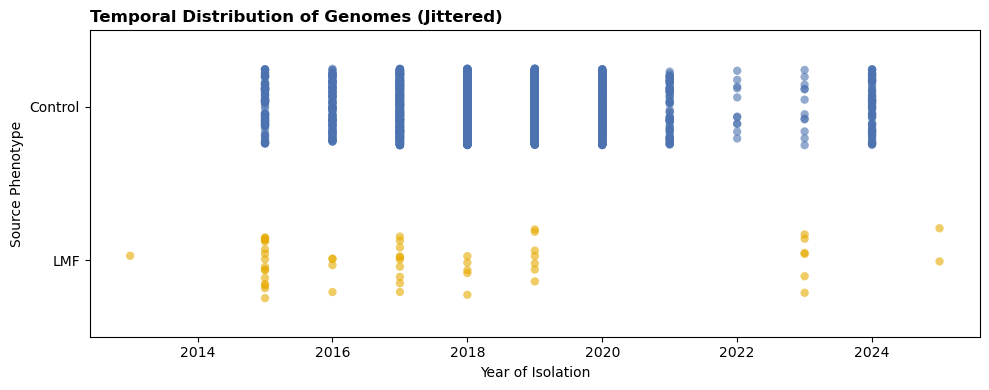

In [47]:
# ---------------------------------------------------------
# 4. PLOT FIGURE 1 (Temporal Jittered)
# ---------------------------------------------------------
import matplotlib.ticker as ticker

fig1, ax1 = plt.subplots(figsize=(10, 4))

# Using seaborn's stripplot which automatically adds jitter to discrete/time data!
sns.stripplot(
    data=df_final, 
    x='Year', 
    y='phenotype',       # Separates Control and LMF on the Y-axis
    hue='phenotype',
    jitter=0.25,         # Adjust this value to make the scatter wider or narrower
    alpha=0.6,           # Makes points slightly transparent to see overlaps
    size=6,
    palette={'LMF': '#e6aa00', 'Control': '#4c72b0'}, # Match custom palette
    ax=ax1
)

ax1.set_title('Temporal Distribution of Genomes (Jittered)', loc='left', fontweight='bold')
ax1.set_xlabel('Year of Isolation')
ax1.set_ylabel('Source Phenotype')

# Ensure the x-axis only shows whole years (no decimals like 2020.5)
ax1.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

fig1.tight_layout()
fig1.savefig('Figure1_Temporal_Jitter.tiff', dpi=600)
print("Figure 1 (Temporal Jitter) generated.")

Figure 1 (Temporal) generated.


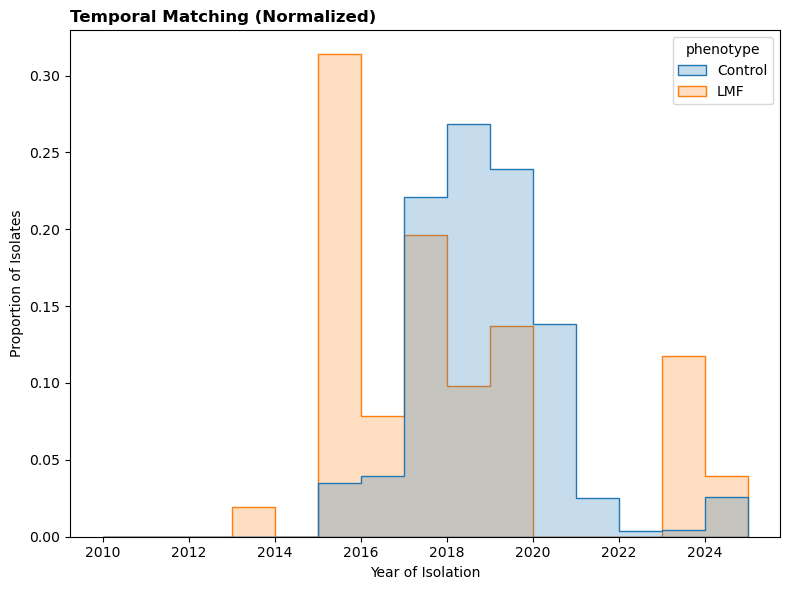

In [49]:
# ---------------------------------------------------------
# 4. PLOT FIGURE 1 (Original Temporal Histogram)
# ---------------------------------------------------------
fig1, ax1 = plt.subplots(figsize=(8, 6))

sns.histplot(
    data=df_final, x='Year', hue='phenotype', 
    element='step', stat='probability', common_norm=False, 
    bins=range(2010, 2026), ax=ax1
)

ax1.set_title('Temporal Matching (Normalized)', loc='left', fontweight='bold')
ax1.set_ylabel('Proportion of Isolates')
ax1.set_xlabel('Year of Isolation')

fig1.tight_layout()
fig1.savefig('Figure1_Temporal.tiff', dpi=300)
print("Figure 1 (Temporal) generated.")